In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df.shape

(200, 5)

In [9]:
X= df[['Annual Income (k$)','Spending Score (1-100)']]

In [10]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


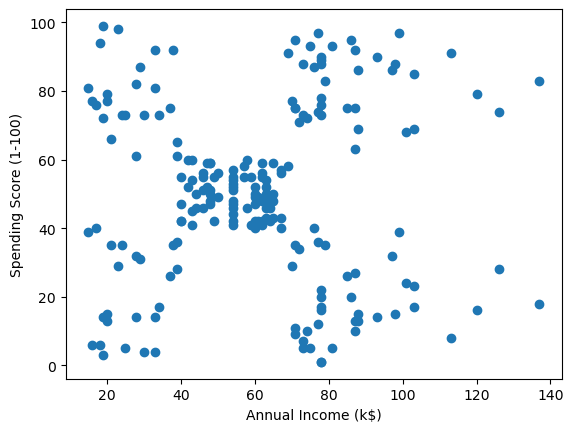

In [11]:
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [15]:
scaler= StandardScaler()
X_scaled=scaler.fit_transform(X)

# Apply K-Means

In [16]:
kmeans= KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
    )

In [17]:
kmeans.fit(X_scaled)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [18]:
df["Cluster"] = kmeans.labels_

In [19]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


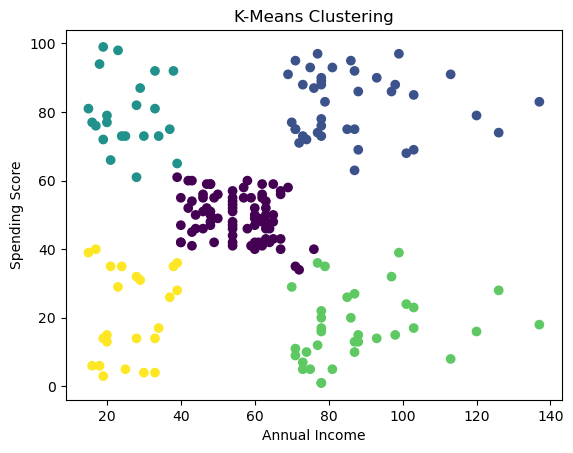

In [20]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")

plt.show()

In [24]:
kmeans.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [51]:
centers= scaler.inverse_transform(kmeans.cluster_centers_)
centers

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

## Find the best number of clusters
<pre> `inertia_`: This measures how tightly grouped the data points are inside their clusters. Lower numbers mean tighter, more compact `clusters.range`(1, 11): It tests cluster sizes from 1 up to 10.KMeans(...): It creates a KMeans clustering model with k clusters. n_init=10 means the algorithm runs 10 times with different starting seeds to find the best result.</pre>

In [32]:
inertia= []
for k in range(1,11):
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

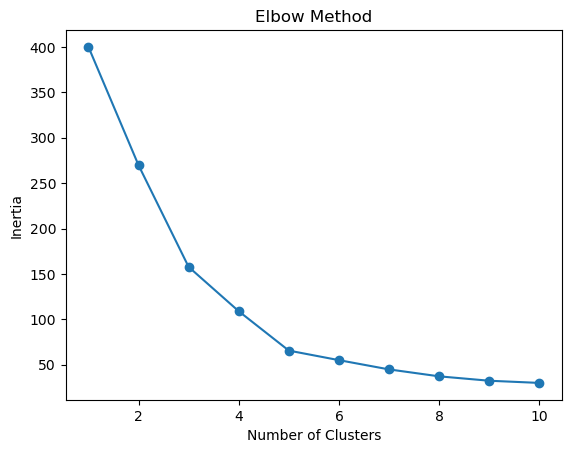

In [52]:
plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

# DBSCAN

In [34]:
from sklearn.cluster import DBSCAN

In [35]:
dbscan=DBSCAN(
    eps=0.5,
    min_samples=5
)

In [39]:
df["DBSCAN"]= dbscan.fit_predict(X_scaled) #The algorithm learns the structure of your scaled data and assigns a cluster label to each row.

In [40]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN
0,1,Male,19,15,39,4,0
1,2,Male,21,15,81,2,0
2,3,Female,20,16,6,4,0
3,4,Female,23,16,77,2,0
4,5,Female,31,17,40,4,0


In [54]:
df[df["DBSCAN"] == -1] #gives the points DBSCAN considers noise/outlier candidates.

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN,IsolationForest,LOF
191,192,Female,32,103,69,1,-1,1,1
192,193,Male,33,113,8,3,-1,-1,1
194,195,Female,47,120,16,3,-1,1,-1
195,196,Female,35,120,79,1,-1,-1,-1
196,197,Female,45,126,28,3,-1,-1,-1
197,198,Male,32,126,74,1,-1,-1,-1
198,199,Male,32,137,18,3,-1,-1,-1
199,200,Male,30,137,83,1,-1,-1,-1


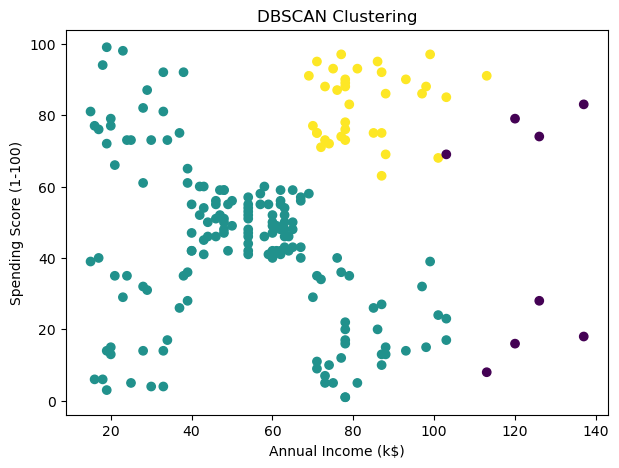

In [55]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["DBSCAN"],
    cmap="viridis"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")

plt.show()

# Isolation Forest

In [42]:
from sklearn.ensemble import IsolationForest

In [43]:
iso=IsolationForest(
    contamination=0.05,
    random_state=42
)

In [44]:
df["IsolationForest"] = iso.fit_predict(X_scaled)

In [45]:
df[df["IsolationForest"] == -1]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN,IsolationForest
11,12,Female,35,19,99,2,0,-1
19,20,Female,35,23,98,2,0,-1
185,186,Male,30,99,97,1,1,-1
192,193,Male,33,113,8,3,-1,-1
193,194,Female,38,113,91,1,1,-1
195,196,Female,35,120,79,1,-1,-1
196,197,Female,45,126,28,3,-1,-1
197,198,Male,32,126,74,1,-1,-1
198,199,Male,32,137,18,3,-1,-1
199,200,Male,30,137,83,1,-1,-1


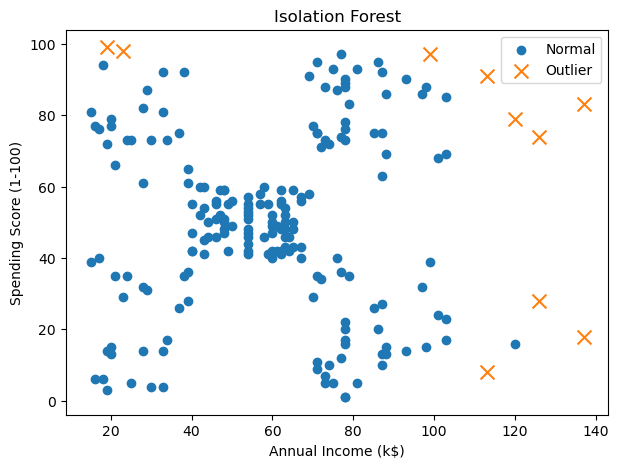

In [56]:
plt.figure(figsize=(7, 5))

normal = df["IsolationForest"] == 1
outlier = df["IsolationForest"] == -1

plt.scatter(
    X.loc[normal, "Annual Income (k$)"],
    X.loc[normal, "Spending Score (1-100)"],
    label="Normal"
)

plt.scatter(
    X.loc[outlier, "Annual Income (k$)"],
    X.loc[outlier, "Spending Score (1-100)"],
    marker="x",
    s=100,
    label="Outlier"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Isolation Forest")
plt.legend()

plt.show()

# LOF

In [46]:
from sklearn.neighbors import LocalOutlierFactor

In [47]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

In [48]:
df["LOF"] = lof.fit_predict(X_scaled)

In [49]:
df[df["LOF"] == -1]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN,IsolationForest,LOF
4,5,Female,31,17,40,4,0,1,-1
132,133,Female,25,72,34,0,0,1,-1
142,143,Female,28,76,40,0,0,1,-1
146,147,Male,48,77,36,3,0,1,-1
194,195,Female,47,120,16,3,-1,1,-1
195,196,Female,35,120,79,1,-1,-1,-1
196,197,Female,45,126,28,3,-1,-1,-1
197,198,Male,32,126,74,1,-1,-1,-1
198,199,Male,32,137,18,3,-1,-1,-1
199,200,Male,30,137,83,1,-1,-1,-1


In [50]:
df[
    [
        "CustomerID",
        "Annual Income (k$)",
        "Spending Score (1-100)",
        "Cluster",
        "DBSCAN",
        "IsolationForest",
        "LOF"
    ]
]

,CustomerID,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN,IsolationForest,LOF
0,1,15,39,4,0,1,1
1,2,15,81,2,0,1,1
2,3,16,6,4,0,1,1
3,4,16,77,2,0,1,1
4,5,17,40,4,0,1,-1
...,...,...,...,...,...,...,...
195,196,120,79,1,-1,-1,-1
196,197,126,28,3,-1,-1,-1
197,198,126,74,1,-1,-1,-1
198,199,137,18,3,-1,-1,-1


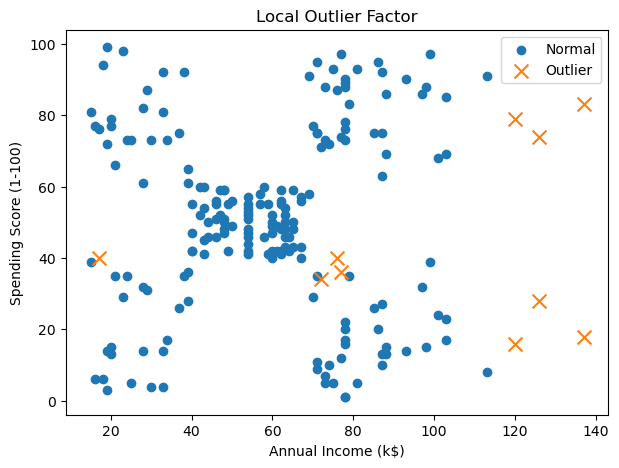

In [57]:
plt.figure(figsize=(7, 5))

normal = df["LOF"] == 1
outlier = df["LOF"] == -1

plt.scatter(
    X.loc[normal, "Annual Income (k$)"],
    X.loc[normal, "Spending Score (1-100)"],
    label="Normal"
)

plt.scatter(
    X.loc[outlier, "Annual Income (k$)"],
    X.loc[outlier, "Spending Score (1-100)"],
    marker="x",
    s=100,
    label="Outlier"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Local Outlier Factor")
plt.legend()

plt.show()